In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import os
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import zeus

from scipy.interpolate import PchipInterpolator, CubicSpline

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
  #  "font.family": "serif",  # Use serif font
 #   "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

In [16]:
# pattern = re.compile(r'(\d{5})')  # Expects date format like '20240708'

# normed_bias2 = []
# sampled_params2 = []
# sampled_sims2 = []

# mean_params2 = []

# bad = np.load(f"{base_dir}/metadata/badsims_emulated.npy", allow_pickle=True)
# good = np.load(f"{base_dir}/metadata/goodsims_emulated.npy", allow_pickle=True)

# fig = plt.figure()

# for i in range(10):
#     # directory = f"{base_dir}/inference/biases/samples_{i}"
#     directory = f"{base_dir}/inference/biases_randomseed5/samples_{i}"
#     for filename in os.listdir(directory):
#         filepath = os.path.join(directory, filename)
#         print(filepath)

#         match = pattern.search(filename)
#         if match:
#             sn = match[0]
#             if sn in sampled_sims2:
#                 print(f'resampled')
#                 continue
#             true_params = np.asarray([*df.loc[sn].to_numpy()])#,
#                                     #    *whatthetau(df.loc[sn].to_numpy())])

#             if not os.path.exists(f"{filepath}/saved_chains.h5"):
#                 continue
#             s, l = utils.load_samples(filepath)
#         #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
#             chain = s[:,:-1]
#             print()
#             print(f"chains shape is {chain.shape}")
#             print()
#             means = np.mean(chain, axis=0)
#             stds = np.std(chain, axis=0)

#             mean_params2.append(means)

#             nbias = (means - true_params[2:]) / stds
#             normed_bias2.append(nbias)

#             sampled_params2.append(true_params)
#             sampled_sims2.append(sn)


# normed_bias2 = np.asarray(normed_bias2)

In [8]:
pattern = re.compile(r'(\d{5})')  # Expects date format like '20240708'

normed_bias = []
sampled_params = []
sampled_sims = []

mean_params = []

bad = np.load(f"{base_dir}/metadata/badsims_emulated.npy", allow_pickle=True)
good = np.load(f"{base_dir}/metadata/goodsims_emulated.npy", allow_pickle=True)

fig = plt.figure()


for i in range(10):
    directory = f"{base_dir}/inference/biases/samples_{i}"
    # directory = f"{base_dir}/inference/biases_randomseed5/samples_{i}"
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        # print(filepath)

        match = pattern.search(filename)
        if match:
            sn = match[0]
            if sn in sampled_sims:
                print(f'resampled')
                continue
            if sn == '18861':
                continue
            if sn == '19048':
                continue
            if sn == '17587':
                continue
            if sn == '17734':
                continue
            true_params = np.asarray([*df.loc[sn].to_numpy()[2:], *whatthetau(df.loc[sn].to_numpy())])

            if not os.path.exists(f"{filepath}/saved_chains.h5"):
                continue
            s, l = utils.load_samples(filepath)
            chain = make_tauchains(s, truths=df.loc[sn].to_dict())
            #chain = s[:,:-1]
            # print()
            # print(f"chains shape is {chain.shape}")
            # print()
            
            ci = 68
            lower_q = (100 - ci) / 2
            upper_q = 100 - lower_q
        
            # Posterior median
            median_val = np.median(chain, axis=0)
        
            # Both bounds in one call
            low, high = np.percentile(chain, [lower_q, upper_q], axis=0)
            low_err = median_val - low
            high_err = high - median_val
            
            # Bias and normalized bias
            bias = median_val - true_params

            sigma_bias = np.zeros_like(bias)
            for bi, bb in enumerate(bias):
                if bb <= 0.0:
                    sigma_bias[bi] = low_err[bi]
                elif bb > 0.0:
                    sigma_bias[bi] = high_err[bi]
        
        # sigma_68_sym = 0.5 * (high - low)  # for bias/σ, use symmetric approx
            nbias = bias / sigma_bias # sigma_68_sym
            normed_bias.append(nbias)

            sampled_params.append(true_params)
            sampled_sims.append(sn)
            
            # means = np.mean(chain, axis=0)
            # stds = np.std(chain, axis=0)

            # mean_params.append(means)

            # nbias = (means - true_params[2:]) / stds
            # normed_bias.append(nbias)

            # sampled_params.append(true_params)
            # sampled_sims.append(sn)

# directory = f"{base_dir}/inference/biases/samples1"
# for filename in os.listdir(directory):
#     filepath = os.path.join(directory, filename)
#     print(filepath)

#     match = pattern.search(filename)
#     if match:
#         sn = match[0]
#         if sn in sampled_sims:
#             print('resampled')
#             continue
#         true_params = np.asarray([*df.loc[sn].to_numpy()])#,
#                                 #    *whatthetau(df.loc[sn].to_numpy())])
#         s, l = utils.load_samples(filepath)
#      #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
#         chain = s[:,:-1]
#         means = np.mean(chain, axis=0)
#         stds = np.std(chain, axis=0)

#         nbias = (means - true_params[2:]) / stds
#         normed_bias.append(nbias)

#         sampled_params.append(true_params)
#         sampled_sims.append(sn)
#         # fig = corner.corner(chain, fig=fig)

# directory = f"{base_dir}/inference/biases/samples3"
# for filename in os.listdir(directory):
#     filepath = os.path.join(directory, filename)
#     print(filepath)

#     match = pattern.search(filename)
#     if match:
#         sn = match[0]
#         if sn in sampled_sims:
#             print('resampled')
#             continue
#         true_params = np.asarray([*df.loc[sn].to_numpy()])#,
#                                 #    *whatthetau(df.loc[sn].to_numpy())])
#         s, l = utils.load_samples(filepath)
#      #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
#         chain = s[:,:-1]
#         means = np.mean(chain, axis=0)
#         stds = np.std(chain, axis=0)

#         nbias = (means - true_params[2:]) / stds
#         normed_bias.append(nbias)

#         sampled_params.append(true_params)
#         sampled_sims.append(sn)
#         # fig = corner.corner(chain, fig=fig)

normed_bias = np.asarray(normed_bias)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10809...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu18850...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10058...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu17242...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu17842...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu16216...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu13192...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu14710...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10988...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu12030...
Loading samples from

<Figure size 640x480 with 0 Axes>

In [4]:
pattern = re.compile(r'(\d{5})')  # Expects date format like '20240708'

biases68 = []
biases95 = []
sampled_sims = []
CI68 = []
CI95 = []

for i in range(10):
    directory = f"{base_dir}/inference/biases/samples_{i}"
    # directory = f"{base_dir}/inference/biases_randomseed5/samples_{i}"
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        # print(filepath)

        match = pattern.search(filename)
        if match:
            sn = match[0]
            if sn in sampled_sims:
                print(f'resampled')
                continue
            if sn in ['18861', '19048', '17587', '17734']:
                continue
            if not os.path.exists(f"{filepath}/saved_chains.h5"):
                continue
                
            s, l = utils.load_samples(filepath, verbose=False)
            nbias68 = normed_bias(s, sn, ci=68)
            nbias95 = normed_bias(s, sn, ci=95)
            samples = make_tauchains(s, truths=df.loc[sn].to_dict(), dropA=True)

            ci = 68
            lower_q = (100 - ci) / 2
            upper_q = 100 - lower_q
            low, high = np.percentile(samples, [lower_q, upper_q], axis=0)
            CI68.append(high-low)
            
            ci = 95
            lower_q = (100 - ci) / 2
            upper_q = 100 - lower_q
            low, high = np.percentile(samples, [lower_q, upper_q], axis=0)
            CI95.append(high-low)
 
            biases68.append(nbias68)
            biases95.append(nbias95)
            sampled_sims.append(sn)
            
biases68 = np.asarray(biases68)
biases95 = np.asarray(biases95)
CI68 = np.asarray(CI68)
CI95 = np.asarray(CI95)

np.save('biases68',biases68, )
np.save( 'biases95', biases95)
np.save(CI68, 'CI68')
np.save(CI95, 'CI95')

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:151: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


resampled
resampled
resampled
resampled
resampled


TypeError: expected str, bytes or os.PathLike object, not ndarray

In [102]:
s, l = utils.load_samples(f"{base_dir}/inference/productionruns3_mechaemu_simu10818/CMB-HD/noiseless/")
s2, l2 = utils.load_samples(f"{base_dir}/inference/productionruns3_mechaemu_simu10818_10emus/CMB-HD/noiseless/")


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_simu10818/CMB-HD/noiseless/...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_simu10818_10emus/CMB-HD/noiseless/...


In [166]:
fidbias2 = (np.mean(s[:,:-1], axis=0) - df.loc['10818'].to_numpy()[2:]) / np.std(s[:,:-1], axis=0)
fidbias3 = (np.mean(s2[:,:-1], axis=0) - df.loc['10818'].to_numpy()[2:]) / np.std(s2[:,:-1], axis=0)

In [104]:
fidbias2, fidbias3

(array([-0.59800657, -0.41483326, -6.63902772]),
 array([-0.56489269, -0.45352335, -6.5224143 ]))

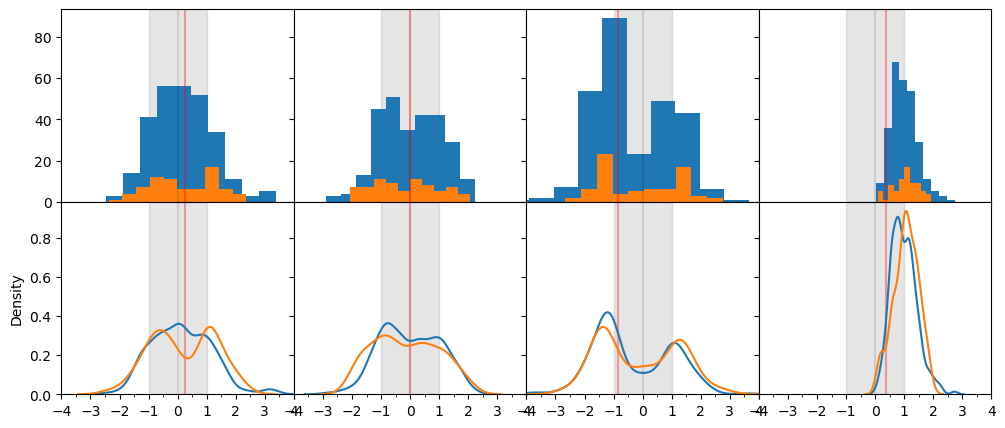

In [12]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(12,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])
fidbias2 = (np.mean(s[:,:-1], axis=0) - df.loc['10818'].to_numpy()[2:]) / np.std(s[:,:-1], axis=0)

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]

# [ax[0,i].axvline(fidbias2[i], color='gold', alpha=.35) for i in range(3)]
# [ax[1,i].axvline(fidbias2[i], color='gold', alpha=.35) for i in range(3)]

# [ax[0,i].axvline(fidbias3[i], color='darkgreen', alpha=.35) for i in range(3)]
# [ax[1,i].axvline(fidbias3[i], color='darkgreen', alpha=.35) for i in range(3)]

[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

[ax[i,-1].axvline(np.mean(np.abs(fidbias)), color='red', alpha=.35) for i in range(2)]
# [ax[i,-1].axvline(np.mean(np.abs(fidbias2)), color='gold', alpha=.35) for i in range(2)]

for i in range(3):
    ax[0,i].hist(np.asarray(normed_bias)[:,i], density=False, bins=10)
    sns.kdeplot(np.asarray(normed_bias)[:,i], ax=ax[1,i], bw_adjust=.75)
    ax[0,i].hist(np.asarray(normed_bias2)[:,i], density=False, bins=10)
    sns.kdeplot(np.asarray(normed_bias2)[:,i], ax=ax[1,i], bw_adjust=.75)
    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(np.abs(normed_bias), axis=1), density=False, bins=10)
sns.kdeplot(np.mean(np.abs(normed_bias), axis=1), ax=ax[1,3], bw_adjust=.75)

ax[0,3].hist(np.mean(np.abs(normed_bias2), axis=1), density=False, bins=10)
sns.kdeplot(np.mean(np.abs(normed_bias2), axis=1), ax=ax[1,3], bw_adjust=.75)

ax[0,0].set_xlim(-4,4)
from matplotlib.ticker import LinearLocator, MultipleLocator
#ax[0,0].xaxis.set_major_locator(LinearLocator(11))

ax[0,0].xaxis.set_major_locator(MultipleLocator(1))
ax[0,0].xaxis.set_minor_locator(MultipleLocator(0.5))

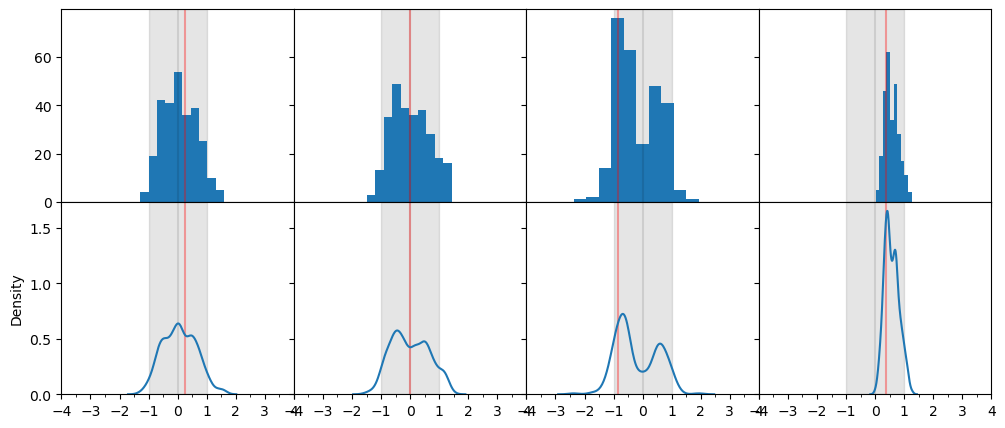

In [15]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(12,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])
fidbias2 = (np.mean(s[:,:-1], axis=0) - df.loc['10818'].to_numpy()[2:]) / np.std(s[:,:-1], axis=0)

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]

# [ax[0,i].axvline(fidbias2[i], color='gold', alpha=.35) for i in range(3)]
# [ax[1,i].axvline(fidbias2[i], color='gold', alpha=.35) for i in range(3)]

# [ax[0,i].axvline(fidbias3[i], color='darkgreen', alpha=.35) for i in range(3)]
# [ax[1,i].axvline(fidbias3[i], color='darkgreen', alpha=.35) for i in range(3)]

[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

[ax[i,-1].axvline(np.mean(np.abs(fidbias)), color='red', alpha=.35) for i in range(2)]
# [ax[i,-1].axvline(np.mean(np.abs(fidbias2)), color='gold', alpha=.35) for i in range(2)]

for i in range(3):
    ax[0,i].hist(np.asarray(normed_bias)[:,i], density=False, bins=10)
    sns.kdeplot(np.asarray(normed_bias)[:,i], ax=ax[1,i], bw_adjust=.75)

    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(np.abs(normed_bias), axis=1), density=False, bins=10)
sns.kdeplot(np.mean(np.abs(normed_bias), axis=1), ax=ax[1,3], bw_adjust=.75)

ax[0,0].set_xlim(-4,4)
from matplotlib.ticker import LinearLocator, MultipleLocator
#ax[0,0].xaxis.set_major_locator(LinearLocator(11))

ax[0,0].xaxis.set_major_locator(MultipleLocator(1))
ax[0,0].xaxis.set_minor_locator(MultipleLocator(0.5))

In [7]:

plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
  #  "font.family": "serif",  # Use serif font
 #   "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

In [10]:
normed_bias.shape, s.shape

((275, 4), (60000, 4))

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_mechaemu/CMB-HD/noiseless...


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:151: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


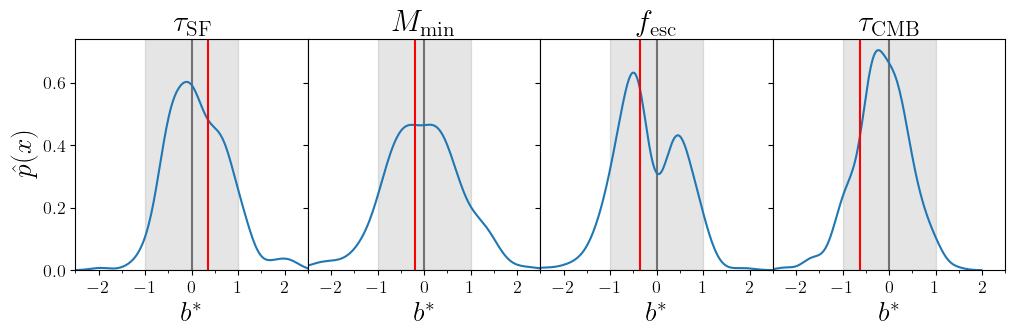

In [7]:
fig, ax = plt.subplots(1,4, sharex=True, sharey='row', figsize=(12,3))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

sHD, l = utils.load_samples(f"{base_dir}/inference/productionruns6_mechaemu/CMB-HD/noiseless")
fidbias = normed_bias(sHD, config.sn, ci=95)
# fidbias2 = (np.mean(s[:,:-1], axis=0) - df.loc['10818'].to_numpy()[2:]) / np.std(s[:,:-1], axis=0)

[a.axvline(0.0, color='black', alpha=.5) for a in ax.flatten()]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

# [ax[i,-1].axvline(np.mean(np.abs(fidbias)), color='red', alpha=.35) for i in range(2)]
# [ax[i,-1].axvline(np.mean(np.abs(fidbias2)), color='gold', alpha=.35) for i in range(2)]


for i in range(4):
    sns.kdeplot(np.asarray(biases95)[:,i], ax=ax[i], bw_adjust=1.0)
    
    ax[i].axvline(fidbias[i], color='red')
    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])


ax[0].set_xlim(-2.5,2.5)
from matplotlib.ticker import LinearLocator, MultipleLocator
#ax[0,0].xaxis.set_major_locator(LinearLocator(11))

[ax[i].set_title(astro_pnames_formatted[2+i], fontsize=22) for i in range(4)]
# ax[3].set_title(r"$\Sigma_{i} |\mathrm{NB}_{i}|$")

[a.set_xlabel(r"$b^*$", fontsize=20) for a in ax]
ax[0].set_ylabel(r"$\,\hat{p}(x)\,$", fontsize=20)

ax[0].xaxis.set_major_locator(MultipleLocator(1))
ax[0].xaxis.set_minor_locator(MultipleLocator(0.5))

fig.savefig('biases.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns6_mechaemu/CMB-HD/noiseless...


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:151: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


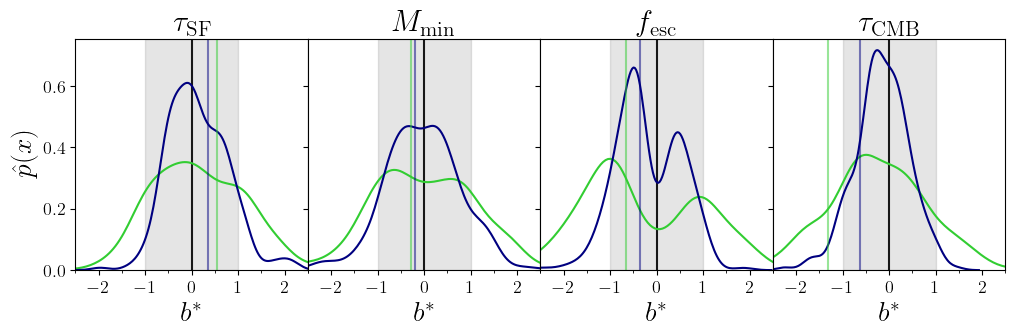

In [38]:
fig, ax = plt.subplots(1,4, sharex=True, sharey='row', figsize=(12,3))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

sHD, l = utils.load_samples(f"{base_dir}/inference/productionruns6_mechaemu/CMB-HD/noiseless")
fidbias68 = normed_bias(sHD, config.sn, ci=68)
fidbias95 = normed_bias(sHD, config.sn, ci=95)
# fidbias2 = (np.mean(s[:,:-1], axis=0) - df.loc['10818'].to_numpy()[2:]) / np.std(s[:,:-1], axis=0)

[a.axvline(0.0, color='black', alpha=.9) for a in ax.flatten()]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

# [ax[i,-1].axvline(np.mean(np.abs(fidbias)), color='red', alpha=.35) for i in range(2)]
# [ax[i,-1].axvline(np.mean(np.abs(fidbias2)), color='gold', alpha=.35) for i in range(2)]

for i in range(4):
    sns.kdeplot(np.asarray(biases68)[:,i], ax=ax[i], bw_adjust=.9, color='limegreen')
    sns.kdeplot(np.asarray(biases95)[:,i], ax=ax[i], bw_adjust=.9, color='navy')
    
    ax[i].axvline(fidbias68[i], color='limegreen', alpha=.5, label='CI 68%')
    ax[i].axvline(fidbias95[i], color='navy', alpha=.5, label='CI 95%')
    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])

ax[0].set_xlim(-2.5,2.5)
from matplotlib.ticker import LinearLocator, MultipleLocator
#ax[0,0].xaxis.set_major_locator(LinearLocator(11))

[ax[i].set_title(astro_pnames_formatted[2+i], fontsize=22) for i in range(4)]
# ax[3].set_title(r"$\Sigma_{i} |\mathrm{NB}_{i}|$")

[a.set_xlabel(r"$b^*$", fontsize=20) for a in ax]
ax[0].set_ylabel(r"$\,\hat{p}(x)\,$", fontsize=20)

ax[0].xaxis.set_major_locator(MultipleLocator(1))
ax[0].xaxis.set_minor_locator(MultipleLocator(0.5))

fig.savefig('biases.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [15]:
CI95

array([[0.55282484, 1.48194556, 0.11749839, 0.0070118 ],
       [0.27140475, 0.6861199 , 0.06771669, 0.00523058],
       [0.5048955 , 1.44578381, 0.12997762, 0.0054063 ],
       ...,
       [0.30379849, 0.91487223, 0.15115085, 0.00577097],
       [0.30130908, 0.92246784, 0.03827866, 0.00538037],
       [0.62331219, 1.50486503, 0.10586027, 0.00573223]], shape=(275, 4))

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_justpriors/CMB-HD/noiseless...


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:151: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[Text(0, 0.5, ''), Text(0, 0.5, ''), Text(0, 0.5, '')]

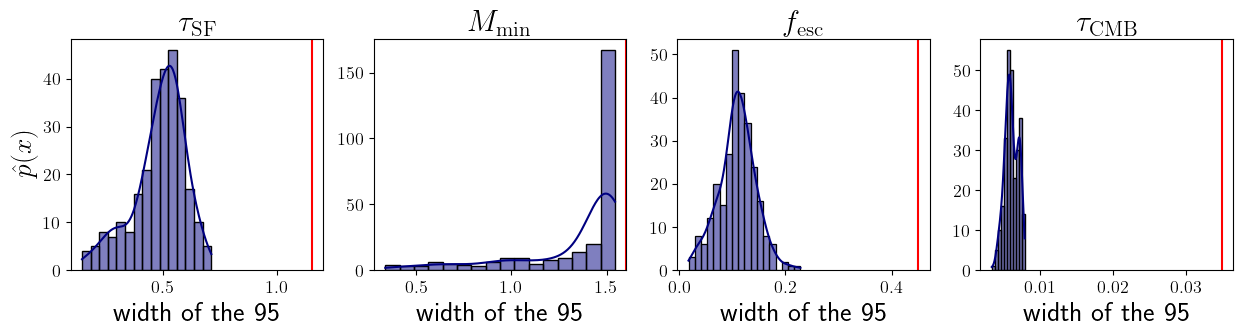

In [34]:
fig, ax = plt.subplots(1,4, figsize=(15,3))

for i in range(4):
  #  sns.kdeplot(CI95[:,i], ax=ax[i], bw_adjust=.9, color='navy')
    sns.histplot(CI95[:,i], ax=ax[i], color='navy', kde=True)
    if i < 3:
        ax[i].axvline(np.max(priors[2+i]) - np.min(priors[2+i]), color='red')
    if i == 3:
        s, l = utils.load_samples(f"{base_dir}/inference/productionruns3_justpriors/CMB-HD/noiseless")
        s = make_tauchains(s[:,:3], A=False, dropA=False, truths=df.loc[config.sn].to_dict())
        width = np.max(s[:,-1]) - np.min(s[:,-1])
        ax[i].axvline(width, color='red')
    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])

# ax[0].set_xlim(-2.5,2.5)
# from matplotlib.ticker import LinearLocator, MultipleLocator
#ax[0,0].xaxis.set_major_locator(LinearLocator(11))

[ax[i].set_title(astro_pnames_formatted[2+i], fontsize=22) for i in range(4)]
# ax[3].set_title(r"$\Sigma_{i} |\mathrm{NB}_{i}|$")

[a.set_xlabel("width of the 95% credible interval", fontsize=20) for a in ax]
ax[0].set_ylabel(r"$\,\hat{p}(x)\,$", fontsize=20)

[a.set_ylabel('') for a in ax[1:]]

# ax[0].xaxis.set_major_locator(MultipleLocator(1))
# ax[0].xaxis.set_minor_locator(MultipleLocator(0.5))

# fig.savefig('biases.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [33]:
priors

array([[-3.71669877, -1.71669877],
       [ 0.        ,  1.        ],
       [ 2.86858567,  4.02138365],
       [ 8.        ,  9.6       ],
       [ 0.05      ,  0.5       ]])

In [8]:
mob = []

for i in range(5):
    print(f"Now on {i} run...")
    emu = summon_emu(f"setrandomseed3/emuv5.1_run{i}")
    mob.append(emu)

Now on 0 run...
Now on 1 run...
Now on 2 run...
Now on 3 run...
Now on 4 run...


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [13]:
all_params = df.to_numpy()
all_emuKSZ = emulator.kemu(all_params, mob)
all_truKSZ = np.zeros_like(all_emuKSZ)

for i, sn in enumerate(df.index):
    all_truKSZ[i] = utils.spectra(sn)[indices]

In [ ]:
fig, ax = plt.subplots(1, len(df.columns), figsize=(20,5))

In [ ]:
def degeneracy(Mmin, slope=priors2d['m'], intercept=priors2d['b_below']):
    return priors2d['m'] * Mmin + priors2d['b_below']

m -0.3829816420010991
b_above 7.092322026855919
b_below 6.538693189693441


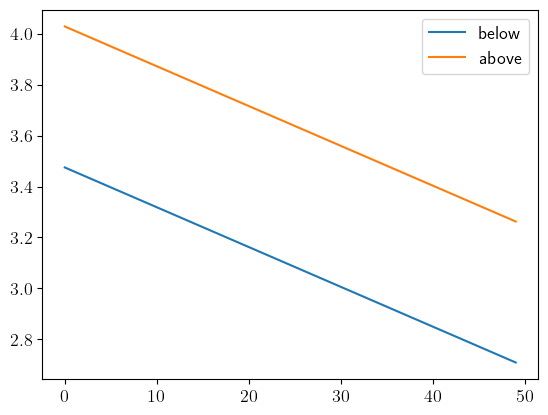

In [52]:
for key in priors2d:
    print(key, priors2d[key])

plt.plot(priors2d['m'] * np.linspace(8,10) + priors2d['b_below'], label='below')
plt.plot(priors2d['m'] * np.linspace(8,10) + priors2d['b_above'], label='above')

plt.legend()

In [113]:
if '13925' in bad:
    print('true')
else:
    print('not true')


not true
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [62]:
err = np.load("/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed5/ensemble_error_v5.1.npy")
err

array([0.00609426, 0.00770746, 0.01331136, ..., 0.01316332, 0.00542797,
       0.00623588], shape=(1359,))

In [ ]:
for i, sn in enumerate(sampled_sims):
    print(sn)
    if sn in bad_nb:

In [ ]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])

good_nb = []
bad_nb = []

for i, sn in enumerate(sampled_sims):
    if sn in bad:
        bad_nb.append(normed_bias[i])
    elif sn in good:
        good_nb.append(normed_bias[i])

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

for i in range(3):
    ax[0,i].hist(np.asarray(good_nb)[:,i], density=False)
    sns.kdeplot(np.asarray(good_nb)[:,i], ax=ax[1,i])
    ax[0,i].hist(np.asarray(bad_nb)[:,i], density=True)
    sns.kdeplot(np.asarray(bad_nb)[:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(np.asarray(good_nb), axis=1), density=True, label="good sims")
sns.kdeplot(np.mean(np.asarray(good_nb), axis=1), ax=ax[1,3])

ax[0,3].hist(np.mean(np.asarray(bad_nb), axis=1), density=True, label="bad sims")
sns.kdeplot(np.mean(np.asarray(bad_nb), axis=1), ax=ax[1,3])

ax[0,0].set_xlim(-4.2,4.2)
ax[0,3].legend()

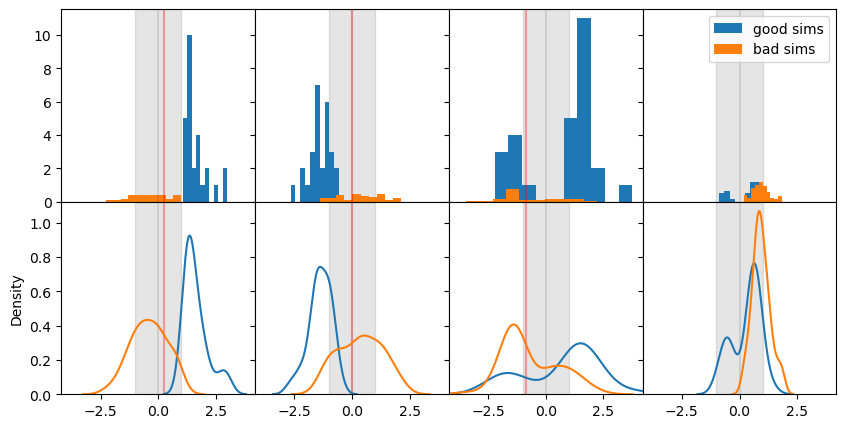

In [124]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

lowbias = normed_bias[:,0] > 1.0

for i in range(3):
    ax[0,i].hist(normed_bias[lowbias][:,i], density=False)
    sns.kdeplot(normed_bias[lowbias][:,i], ax=ax[1,i])
    ax[0,i].hist(normed_bias[~lowbias][:,i], density=True)
    sns.kdeplot(normed_bias[~lowbias][:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(normed_bias[lowbias], axis=1), density=True, label="good sims")
sns.kdeplot(np.mean(normed_bias[lowbias], axis=1), ax=ax[1,3])

ax[0,3].hist(np.mean(np.abs(normed_bias)[~lowbias], axis=1), density=True, label="bad sims")
sns.kdeplot(np.mean(np.abs(normed_bias)[~lowbias], axis=1), ax=ax[1,3])

ax[0,0].set_xlim(-4.2,4.2)
ax[0,3].legend()

In [47]:
p2 = (2.9766250520507276, 9.6)
p1 = (3.589379844241917, 8.0)

slope, intercept = np.polyfit([p1[1], p2[1]], [p1[0],p2[0]], 1)

In [128]:
config.sn

'12958'

3.8053853027834923 8.0
3.9133846421530856 8.0
3.589379844241917 8.0
3.48138529211277 8.0
3.6973862883068946 8.0
4.021383654057061 8.0


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_7394/3963296080.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(fontsize=20)


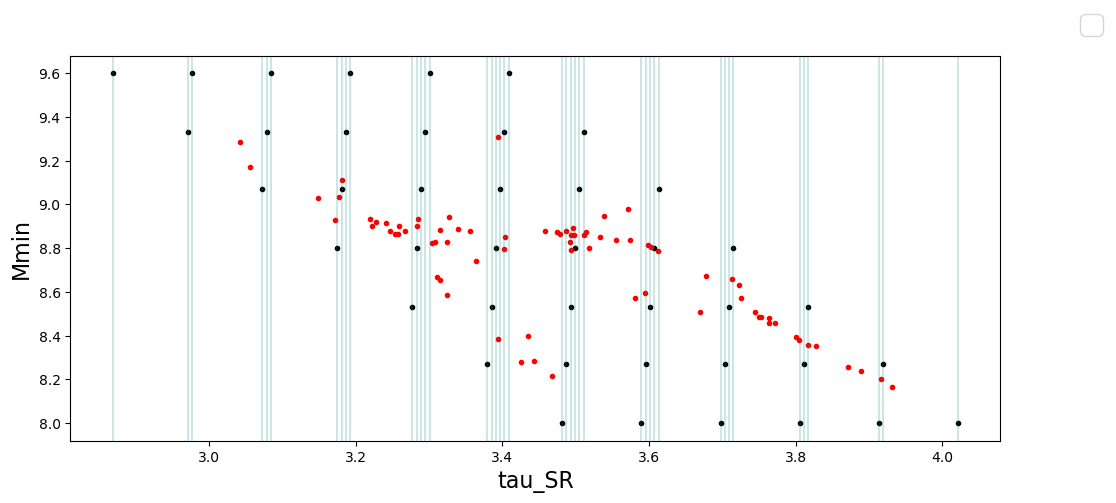

In [48]:
import itertools
fig, ax = plt.subplots(figsize=(12,5))

xMmin_dots = np.asarray(sorted(df['Mmin'].unique()))

unique_pairs = set(
    tuple(sorted(pair)) for pair in zip(df['tau'], df['Mmin'])
)

for pair in unique_pairs:
    x, y = pair
    if y == 8.0:
        print(x,y)
    ax.plot(x, y, marker='.', color='black')


for p in mean_params:
    ax.plot(p[0], p[1], marker='.', color='red')


# ax.plot(degeneracy(xMmin), xMmin, alpha=.75, color='navy', label='Degeneracy Line 1')
# ax.plot(xtau_2ndslope, xMmin, alpha=.75, color='gold', label='Degeneracy Line 2')

for t in df['tau'].unique():
    ax.axvline(t, color='teal', alpha=.2)

ax.set_ylabel('Mmin', fontsize=16)
ax.set_xlabel('tau_SR', fontsize=(16))

fig.legend(fontsize=20)

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


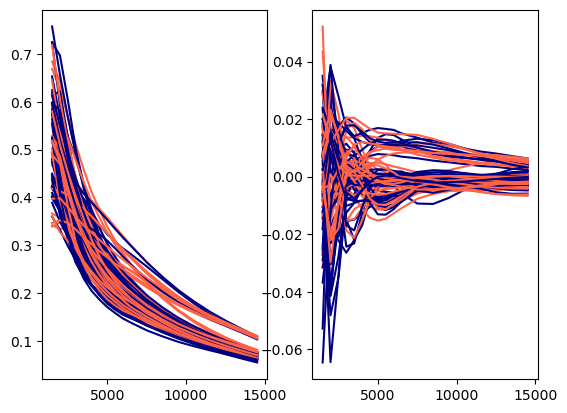

In [31]:
fig, ax = plt.subplots(1,2)

mob = []
for i in range(5):
    emu = summon_emu(f"setrandomseed3/emuv5.1_run{i}")
    mob.append(emu)

for i, sn in enumerate(sampled_sims):
    spec = utils.spectra(sn)[indices]
    
    if lowbias[i]:
        color = 'navy'
    elif not lowbias[i]:
        color = 'tomato'
    ax[0].plot(ells[indices], spec, color=color)
    ax[1].plot(ells[indices], emulator.mechkemu(df.loc[sn].to_numpy(), mob) - spec, color=color)

In [ ]:
fig, ax = plt.subplots(1,2)

mob = []
for i in range(5):
    emu = summon_emu(f"setrandomseed3/emuv5.1_run{i}")
    mob.append(emu)

for i, sn in enumerate(df.index):
    tspec = utils.spectra(sn)[indices]
    espec = emulator.mechkemu(df.loc[sn].to_numpy(), mob)
    residual =  espec - tspec
    
    # if lowbias[i]:
    #     color = 'navy'
    # elif not lowbias[i]:
    #     color = 'tomato'
    ax[0].plot(ells[indices], tspec, color='navy', alpha=.1)
    ax[0].plot(ells[indices], espec, color='tomato', alpha=.1)
    ax[1].plot(ells[indices], residual, color='black', alpha=.1)

In [ ]:
min_z = []
for redshifts in all_z:
    min_z.append(redshifts.min())


In [ ]:
np.asarray(min_z).max(), df.index[np.asarray(min_z).argmax()]

In [ ]:
y_interp = np.interp(x_interp, x, y)

In [ ]:
all_z[0]

In [151]:
sfr_data = np.genfromtxt(f"{base_dir}/metadata/sfr_dens.dat").T

In [158]:
sfr_data[0][4:]

array([ 7.7885,  7.9808,  8.9663,  8.9904,  9.9519, 10.1683, 10.3846])

In [64]:
emulator.kemu(df.loc[config.sn].to_numpy(), **emu)

array([0.01054958, 0.00904768, 0.0052955 , 0.00298971, 0.00282189,
       0.00221926], dtype=float32)

In [65]:
params

array([-1.71669877,  0.        ,  1.25745477,  1.25745477,  1.25745477])

In [222]:
def chi2_sfr(model, data=sfr_obs[4:], err=sfr_err[4:], debug=False):
    if debug:
        print((model - data).shape)
        print(f"model: {model}")
        print(f"data: {data}")
        print(f"err: {err}")
        print(f"model - data: {model - data}")
        print((model - data)**2 / err**2)
        print()
    return np.sum((model - data)**2 / err**2, axis=1)


On 6796th sample


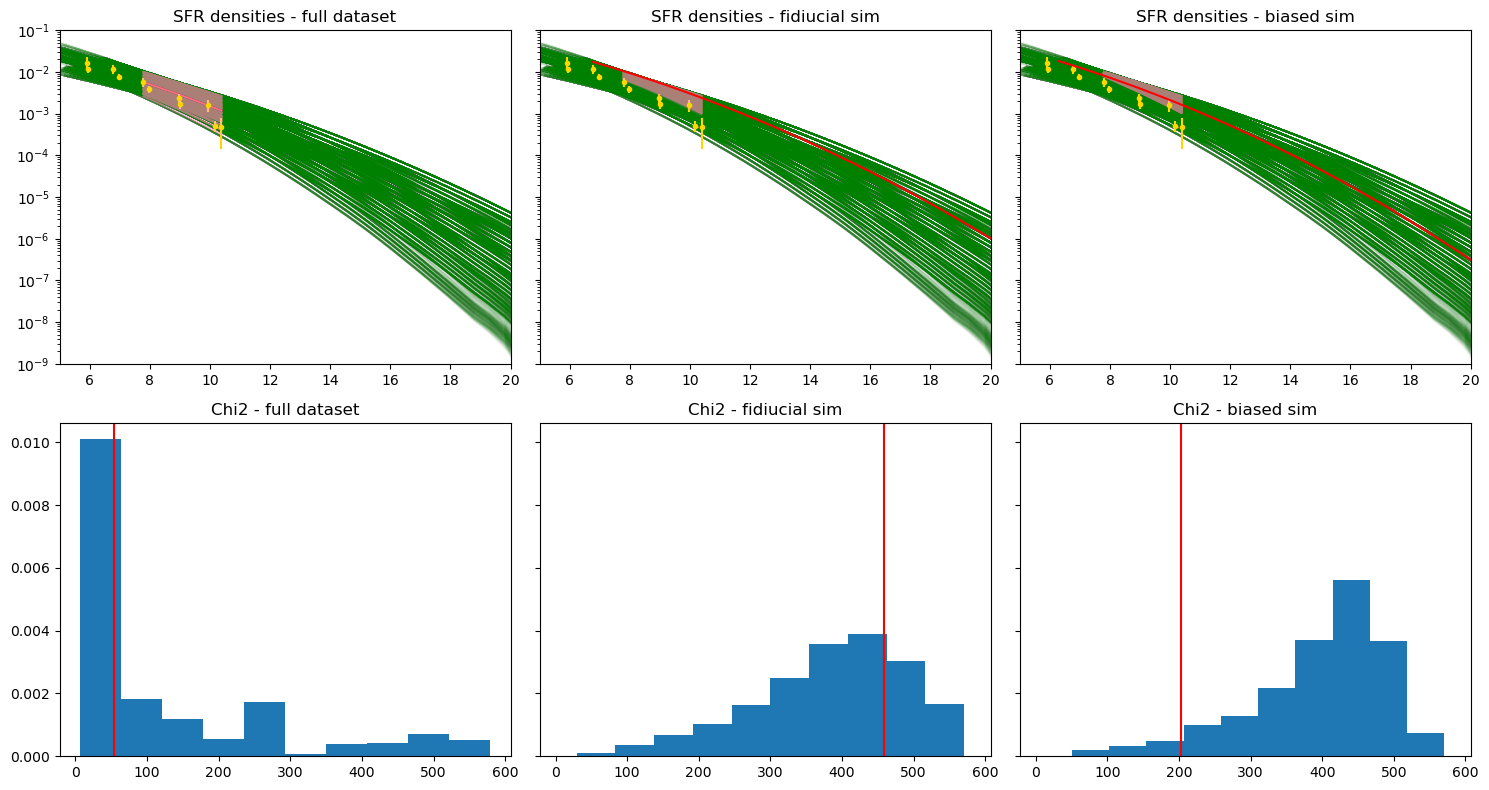

In [228]:
fig, axes = plt.subplots(2,3, sharex='row', sharey='row', figsize=(15,8))
# fig.subplots_adjust(wspace=0.0, hspace=0.1)

directory = f"{base_dir}/metadata/diagnostic_files"

sfr_z = sfr_data[0]#[4:]
sfr_obs = sfr_data[1]#[4:]
sfr_err = sfr_data[2]#[4:]

z_interp = sfr_z[4:]

dataset = np.zeros((len(df), len(z_interp)))
features = np.zeros((len(df), 5))

all_SFR = []
all_z  = []

ax = axes[0]
for i, sn in enumerate(df.index):
   #ax.semilogy(all_z[i],all_SFR[i], color='green', alpha=.01)
    filename = f"simu{sn}_diagnostics.dat"
    path = os.path.join(directory, filename)
    fdata = np.genfromtxt(path).T

    z_sf = fdata[0]
    sfr = fdata[4]
  
    SFR_interp = np.interp(z_interp, z_sf[::-1], sfr[::-1])

    dataset[i] = SFR_interp
    features[i] = df.loc[sn].to_numpy()

    ax[0].semilogy(z_sf, sfr, color='green', alpha=.01)
    ax[1].semilogy(z_sf, sfr, color='green', alpha=.01)
    ax[2].semilogy(z_sf, sfr, color='green', alpha=.01)
    if sn == config.sn:
        ax[1].semilogy(z_sf, sfr, color='red', zorder=1000)
    if sn == '10818':
        ax[2].semilogy(z_sf, sfr, color='red', zorder=1000)
    # ax.semilogy(z_interp, SFR_interp, color='pink', alpha=.1)

ax[0].semilogy(z_interp, emulator.kemu(df.to_numpy().mean(axis=0), **emu).T, color='red')

ax[0].errorbar(sfr_z, sfr_obs, yerr=sfr_err, color='gold', marker='.', ls='')
ax[1].errorbar(sfr_z, sfr_obs, yerr=sfr_err, color='gold', marker='.', ls='')
ax[2].errorbar(sfr_z, sfr_obs, yerr=sfr_err, color='gold', marker='.', ls='')

emu = {'scalerX': nn.scalerX,
       'scalerY': nn.scalerY,
       'model': nn.model}

print(f"On {i}th sample")
paramsfid = fill(s[:-1], df.loc[config.sn].to_dict(), df.columns[2:])
params10818 = fill(s10818[:-1], df.loc[config.sn].to_dict(), df.columns[2:])

ax[0].semilogy(z_interp, emulator.kemu(df.to_numpy(), **emu).T, color='pink', alpha=.01)
ax[1].semilogy(z_interp, emulator.kemu(paramsfid, **emu).T, color='pink', alpha=.01)
ax[2].semilogy(z_interp, emulator.kemu(params10818, **emu).T, color='pink', alpha=.01)

ax[0].set_title('SFR densities - full dataset')
ax[1].set_title('SFR densities - fidiucial sim')
ax[2].set_title('SFR densities - biased sim')
ax[0].set_xlim(5.0, 20.0)
# ax.set_xlim(z_interp.min(), z_interp.max())
ax[0].set_ylim(10e-10, 10e-2)

ax = axes[1]

chi2_all = chi2_sfr(emulator.kemu(df.to_numpy(), **emu))

ax[0].hist(chi2_all, density=True)
ax[1].hist(chi2_sfr(emulator.kemu(paramsfid, **emu)), density=True)
ax[2].hist(chi2_sfr(emulator.kemu(params10818, **emu)), density=True)

ax[0].axvline(chi2_sfr(emulator.kemu(np.array([df.to_numpy().mean(axis=0)]), **emu)), color='red')
ax[1].axvline(chi2_sfr(emulator.kemu(np.array([df.loc[config.sn].to_numpy()]), **emu)), color='red')
ax[2].axvline(chi2_sfr(emulator.kemu(np.array([df.loc['10818'].to_numpy()]), **emu)), color='red')

ax[0].set_title('Chi2 - full dataset')
ax[1].set_title('Chi2 - fidiucial sim')
ax[2].set_title('Chi2 - biased sim')

fig.tight_layout()


In [221]:
ax[0].axvline(chi2_sfr(emulator.kemu(np.array([df.to_numpy().mean(axis=0)]), **emu)), color='red')
ax[1].axvline(chi2_sfr(emulator.kemu(np.array([df.loc[config.sn].to_numpy()]), **emu)), color='red')
ax[2].axvline(chi2_sfr(emulator.kemu(np.array([df.loc['10818'].to_numpy()]), **emu)), color='red')

(1, 7)
model: [[0.00577106 0.0051344  0.00288498 0.00286729 0.00156436 0.00136302
  0.00117792]]
data: [0.005697  0.003903  0.002333  0.0016879 0.0015965 0.0005138 0.0004737]
err: [0.001373  0.000686  0.000563  0.0004071 0.0004945 0.0001413 0.0003346]
model - data: [[ 7.40590772e-05  1.23139765e-03  5.51983551e-04  1.17939471e-03
  -3.21428031e-05  8.49219110e-04  7.04221775e-04]]
[[2.90948095e-03 3.22216971e+00 9.61248073e-01 8.39297916e+00
  4.22507968e-03 3.61206197e+01 4.42962565e+00]]

(1, 7)
model: [[0.01010486 0.00918266 0.00540453 0.00532021 0.00306895 0.0026972
  0.00237421]]
data: [0.005697  0.003903  0.002333  0.0016879 0.0015965 0.0005138 0.0004737]
err: [0.001373  0.000686  0.000563  0.0004071 0.0004945 0.0001413 0.0003346]
model - data: [[0.00440786 0.00527966 0.00307153 0.00363231 0.00147245 0.0021834
  0.00190051]]
[[ 10.30659228  59.23292857  29.76401007  79.60938674   8.86645849
  238.7714519   32.26195248]]

(1, 7)
model: [[0.00835086 0.00748444 0.0042181  0.00415651

In [218]:
chi2_sfr(emulator.kemu(np.array([df.to_numpy().mean(axis=0)]), **emu))

(1, 7)
model: [[0.00577106 0.0051344  0.00288498 0.00286729 0.00156436 0.00136302
  0.00117792]]
data: [0.005697  0.003903  0.002333  0.0016879 0.0015965 0.0005138 0.0004737]
err: [0.001373  0.000686  0.000563  0.0004071 0.0004945 0.0001413 0.0003346]
model - data: [[ 7.40590772e-05  1.23139765e-03  5.51983551e-04  1.17939471e-03
  -3.21428031e-05  8.49219110e-04  7.04221775e-04]]


array([53.1337769])

In [219]:
7.40590772e-05 / 0.001373

0.053939604661325566

In [192]:
s,l = utils.load_samples(f"/Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless")
s10818,l = utils.load_samples(f"/Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_simu10818/CMB-HD/noiseless")

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_simu10818/CMB-HD/noiseless...


In [184]:
validation_sims = np.load(f'{base_dir}/emulators/setrandomseed3/validation_sims.npy', allow_pickle=True)
training_files = np.load(f"{base_dir}/emulators/setrandomseed3/emuv5.1_run0/training_files.npz", allow_pickle=True)

hyperparameters = training_files['config'].item()
hyperparameters['uncertainties'] = None
hyperparameters

nn = emulator.NeuralNetwork(hyperparameters, dataset=dataset, features=features, verbose=True)
nn.prep_data()
nn.regress()

prepping data for regression...
logging input data...
scaling features and data...
running regression with config:
	 {'neurons': 32, 'epochs': 500, 'nlayers': 2, 'uncertainties': None, 'batch_normalize': True, 'add_dropout': True, 'early_stop': True, 'reduce_lr': True}
Epoch 1/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4080 - val_loss: 0.7750 - learning_rate: 0.0010
Epoch 2/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - loss: 0.4915 - val_loss: 0.4121 - learning_rate: 0.0010
Epoch 3/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - loss: 0.3078 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 4/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - loss: 0.2523 - val_loss: 0.1033 - learning_rate: 0.0010
Epoch 5/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - loss: 0.2066 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 6/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - loss: 0.1830 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 7/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - loss: 0.164

In [ ]:
fig, ax = plt.subplots()

import os
import re

directory = f"{base_dir}/metadata/diagnostic_files"

dataset = np.zeros((len(df), 5))
features = np.zeros((len(df), 5))

# Regex to extract the first number in the filename
number_pattern = re.compile(r'\d+')

for filename in os.listdir(directory):
    path = os.path.join(directory, filename)
    if os.path.isfile(path):
        match = number_pattern.search(filename)
        if match:
            number = int(match.group())
         #   print(f"Found number {number} in file: {filename}")

            fdata = np.genfromtxt(path).T
            ax.semilogy(fdata[0], fdata[4], color='green', alpha=.2)

ax.set_xlim(5.0, 20.0)



In [ ]:
fig, ax = plt.subplots(2,5, sharex='col', sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

# [a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
# [ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
# [ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
# [a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

sampled_params = np.asarray(sampled_params)

for i in range(5):
    ax[0,i].hist(df.to_numpy()[:,i], density=False, color='black', alpha=.2)
    sns.kdeplot(df.to_numpy()[:,i], ax=ax[1,i], color='black', alpha=.2)

    ax[0,i].hist(sampled_params[lowbias][:,i], density=False)
    sns.kdeplot(sampled_params[lowbias][:,i], ax=ax[1,i])
    ax[0,i].hist(sampled_params[~lowbias][:,i], density=True)
    sns.kdeplot(sampled_params[~lowbias][:,i], ax=ax[1,i])



# ax[0,0].set_xlim(-4.2,4.2)
ax[0,3].legend()

In [ ]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

for i in range(3):
    ax[0,i].hist(np.asarray(normed_bias)[:,i], density=False)
    sns.kdeplot(np.asarray(normed_bias)[:,i], ax=ax[1,i])
    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(np.asarray(normed_bias), axis=1), density=True)
sns.kdeplot(np.mean(np.asarray(normed_bias), axis=1), ax=ax[1,3])

ax[0,0].set_xlim(-4.2,4.2)

In [ ]:
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

chains_all = []

for survey in survey_labels:
    chains = []
    for setup in setups:
        s, l = utils.load_samples(f"{base_dir}/inference/productionruns2_mechaemu/{survey}/{setup}")
        chains.append(s)

    chains_all.append(chains)

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 0
chains = chains_all[index]



for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 1
chains = chains_all[index]



for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 2
chains = chains_all[index]

for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

In [ ]:
from datetime import datetime
import os
import re

directory = f"{base_dir}/metadata/diagnostic_files"
pattern = re.compile(r'(\d{5})')  # Expects date format like '20240708'

SFR_histories = {}

for filename in os.listdir(directory):
    filepath = os.path.join(directory, filename)
    if os.path.isfile(filepath):
        match = pattern.search(filename)
        if match:
            sn = match[0]
            diagnostic_file = np.genfromtxt(filepath)
            z = diagnostic_file[:,0]
            SFR = diagnostic_file[:,4]

            history = {'z': z,
                       'SFR': SFR}
            
            SFR_histories[sn] = history

In [ ]:
SFR_histories[sfrh]['SFR']

In [ ]:
# features = np.

min_z = []
fig, ax = plt.subplots()

for sfrh in SFR_histories:
    if sfrh not in df.index:
        continue
    hist = SFR_histories[sfrh]
    z = hist['z']
    sfr = hist['SFR']

    min_z.append(z.min())

    ax.semilogy(z, sfr, color='blue', alpha=.25)

ax.semilogy(SFR_histories[config.sn]['z'], SFR_histories[config.sn]['SFR'], color='gold', alpha=1.0)

ax.set_xlim(5.0,20.0)


In [ ]:
features = np.zeros((len(df), len(df.columns)))
dataset = np.zeros((len(df), ))

In [ ]:
whatthetau(df.loc[config.sn].to_numpy())[0]

In [ ]:
fig, ax = plt.subplots(4, len(survey_labels), sharex=True, sharey='row', figsize=(15,15))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

for i, label in enumerate(survey_labels):
    chains = chains_all[i]
    # lps = lps_all[i]
    # datas = datas_all[i]
    # nruns = len(chains)
    for n, setup in enumerate(setups):
        chain = chains[n]
        # lp = lps[n]
        # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin

        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True

        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())

        for ip, p in enumerate(true_params[2:]):
            ax[ip,i].axhline(p, alpha=.2, color='black')
            ax[ip,i].violinplot(chain[:,ip], [n+1], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,i].set_xticks(np.arange(1, len(setups)+1))
    ax[3,i].set_xticklabels([f"{survey} {setup}" for si, setup in enumerate(setups)])
        
    ax[0,i].set_title(f'{label}', fontsize=12)


In [ ]:
match = (df.drop(columns='tau') == df.loc[config.sn].drop(labels='tau')).all(axis=1)

# Get matching rows
matching_rows = df[match]
matching_rows

In [ ]:
for sn in df[df['fesc']==.275].index:
    if sn
    if np.abs(df.loc[sn]['tau'] - df['tau'].mean()) < .1:
        print(df.loc[sn])

In [ ]:
priors

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

i = 2

chain, lp = utils.load_samples(f"{base_dir}/inference/productionruns_fittingtruezeus/CMB-HD{setup}")
A = False
chain = make_tauchains(chain, A=A)
print(f"Setup {dir[i]} has {chain.shape} samples")
#  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                            hist_kwargs={'density':True}, plot_datapoints=False,
                            levels=[0.393, 0.675, 0.864], fig=fig)

axes = np.array(fig.axes).reshape((ndim, ndim))


plot_kwargs['color'] = 'gray'
# Get indices of values sorted in descending order
top_indices = np.argsort(lp)[-20:][::-1]  # top 20, highest first
for top in top_indices:
    plot_vlines(chain[top], axes, **plot_kwargs)


MAP = chain[np.argmax(lp)]
print(f"MAP values are: {MAP}")
plot_kwargs['color'] = colors[i]
plot_kwargs['ls'] = '-'
plot_kwargs['alpha'] = .5
plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['alpha'] = 1.0
plot_kwargs['ls'] = '--'
plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# # Create custom legend handles
# handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# # Create the legend
# fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])


chain, lp = utils.load_samples(f"{base_dir}/inference/productionruns_fittingtrue2zeus/CMB-HD{setup}")
A = False
chain = make_tauchains(chain, A=A)
print(f"Setup {dir[i]} has {chain.shape} samples")
#  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                            hist_kwargs={'density':True}, plot_datapoints=False,
                            levels=[0.393, 0.675, 0.864], fig=fig)

axes = np.array(fig.axes).reshape((ndim, ndim))


plot_kwargs['color'] = 'gray'
# Get indices of values sorted in descending order
top_indices = np.argsort(lp)[-20:][::-1]  # top 20, highest first
for top in top_indices:
    plot_vlines(chain[top], axes, **plot_kwargs)


MAP = chain[np.argmax(lp)]
print(f"MAP values are: {MAP}")
plot_kwargs['color'] = colors[i]
plot_kwargs['ls'] = '-'
plot_kwargs['alpha'] = .5
plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['alpha'] = 1.0
plot_kwargs['ls'] = '--'
plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# # Create custom legend handles
# handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# # Create the legend
# fig.legend(handles=handles, loc='upper right')

In [ ]:
np.vstack([priors, np.array([Planck - 5 * Planck_err, Planck + 5 * Planck_err])])

In [ ]:
# Build the full dataframe
dfs = []
for s in range(S):
    df = pd.DataFrame(chains[s], columns=[f'param_{i+1}' for i in range(P)])
    df['survey'] = survey_names[s]
    dfs.append(df)

# Combine all surveys into one dataframe
df_all = pd.concat(dfs, ignore_index=True)

# Melt to long form for Seaborn
df_long = df_all.melt(id_vars='survey', var_name='parameter', value_name='value')


In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10))

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])
print(f"True values are: {truths}")

for i, chain in enumerate(chains):
    lp = lps[i]
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {dir[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                         range=np.vstack([priors, np.array([Planck - 5 * Planck_err, Planck + 5 * Planck_err])])[2:],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    MAP = chain[np.argmax(lp)]
    print(f"==========================")
    print(f"Setup {dir[i]}")
    print(f"==========================")
    print(f"MAP values are: {MAP}")
    plot_kwargs['color'] = colors[i]
    plot_kwargs['ls'] = '-'
    plot_kwargs['alpha'] = .5
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

    plot_kwargs['alpha'] = 1.0
    plot_kwargs['ls'] = '--'
    plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
mcmcdir = "productionruns3"

pnames = [*df.columns[2:], 'tau_CMB']
survey_list = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setup_list = ['', '_noise', '_Planck', '_noise_Planck']


dfs = []
for survey in survey_list:
    for setup in setup_list:

        s, l = utils.load_samples(f"{base_dir}/inference/{mcmcdir}/{survey}{setup}")
        chain = make_tauchains(s)
        df_chain = pd.DataFrame(chain, columns=pnames)
        df_chain['survey'] = survey

        if 'noise' in setup:
            noise = True
        else:
            noise = False
        if 'Planck' in setup:
            Planck = True
        else:
            Planck = False
        
        df_chain['noise'] = noise
        df_chain['Planck'] = Planck

        dfs.append(df_chain)

df_all = pd.concat(dfs, ignore_index=True)


In [ ]:
df_long = df_all.melt(
    id_vars=['survey', 'noise', 'Planck'],
    value_vars=pnames,  # e.g., ['param_1', ..., 'param_5']
    var_name='parameter',
    value_name='value'
)

df_long

In [ ]:
g = sns.catplot(
    data=df_long[df_long['noise'] == False],
    x='survey',             # Group along x-axis by this metadata
    y='value',
    col='parameter',        # One plot per parameter
    kind='violin',
    inner='quart',
    split=True,
    hue='Planck',            # Add another dimension
    dodge=True,
    sharey=False,
    col_wrap=2,
    height=4,
    aspect=1.2
)

for i, ax in enumerate(g.axes.flat):
    print(truths[i])
    ax.axhline(truths[i], color='black', zorder=0)
    ax.set_ylabel(pnames[i])

g.set_xlabels('')

g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.85)
#g.fig.suptitle("Violin Plots of MCMC Parameters by Region and Model")


In [ ]:
fig, ax = plt.subplots(1,4)

for i, param in enumerate(truths):
    sns.violinplot(data=df_long, x='', ax=ax[i], hue='noise')

In [ ]:
fig, ax = plt.subplots(2, len(survey_list), sharey=True, figsize=(15,5))
fig.subplots_adjust(wspace=0.0)

for i, experiment in enumerate(survey_list):

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=False)
    err_obs =np.sqrt(np.diag(err_cov))

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=True)
    err_fit =np.sqrt(np.diag(err_cov))
  #  print(f"err={err}")

    for j, setup in enumerate(setup_list):
     #   print(f"{experiment}{setup}")

        data = np.load(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}/data.npz", allow_pickle=True)
        data2 = np.load(f"{base_dir}/inference/productionruns1/{experiment}{setup}/data.npz", allow_pickle=True)

        if 'noise' in setup:
            print(f"{experiment} data is: {data['datapoints']}")

        # print(f"Old error: {data2['err']}")
        # print(f"New error: {data['err']}")
        # print()
        # print(f"New / Old: {data['err'] / data2['err']}")
        # print()

        ax[0,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
                            yerr=err_fit[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
        ax[1,i].errorbar(ells[indices][data2['lmask']], data2['datapoints'],
                            yerr=err_fit[data2['lmask']], color=colors[j], label=f"{experiment}{setup}")

        # if 'noise' not in setup:
        #     ax[0,i].plot(ells[indices][data['lmask']], data['datapoints'], color=colors[j], label=f"{experiment}{setup}")
        #     ax[1,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
        #                     yerr=err_fit[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
        # else:
        #     ax[0,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
        #                     yerr=err_obs[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
            
        ax[0,i].legend()

ax[0,0].set_ylim(0.0, 1.0)

In [ ]:
truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])
truths

In [ ]:
truths

In [ ]:
def playtheviolons(chains):
    psamples = np.zeros((len(chains), chains[0].shape[0], len(truths)))

    for ic, chain in enumerate(chains):
        print(f"Now on chain {ic} which looks like {chain.shape}")
        chain = make_tauchains(chain, A=True)
        for ip in range(len(truths)):
            psamples[ic,:,ip] = chain[:,ip]

    return psamples

allparamchains = []
# Loop over subfigures and add a simple plot in each
for chains in [chains_CMBHD, chains_S4, chains_SOLAT]:
    print(chains[0].shape)
    param_chains = playtheviolons(chains)
    print(param_chains.shape)
    allparamchains.append(param_chains)

In [ ]:
prior_draw = draws(int(120000))
prior_draw.shape

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

prior_chain = make_tauchains(prior_draw[:,2:], A=False)
fig = corner.corner(prior_chain, color='black', labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)

for i, chain in enumerate(chains_CMBHD):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)



plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

prior_chain = make_tauchains(prior_draw, A=False)
fig = corner.corner(prior_chain, color='black', labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)

for i, chain in enumerate(chains_CMBHD):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)



plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
print("CMB-HD no Planck")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chains_CMBHD[0], A=A), axis=0) - truths) / np.std(make_tauchains(chains_CMBHD[0], A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

In [ ]:
print("CMB-HD and Planck")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chains_CMBHD[2], A=A), axis=0) - truths) / np.std(make_tauchains(chains_CMBHD[2], A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

In [ ]:
print("CMB-HD and Planck + noise")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chain, A=A), axis=0) - truths) / np.std(make_tauchains(chain, A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

In [ ]:
for i, chain in enumerate(chains_S4):
    chi2_contribution(chain.mean(axis=0), model, data, err, truths=None)

In [ ]:
theta = fill(s.mean(axis=0), data['truths'].item(), df.columns[2:])
theta

In [ ]:
s[::1000].shape

In [ ]:
fig, ax = plt.subplots(4, len(survey_list), sharex=True, sharey=True, figsize=(15,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, experiment in enumerate(survey_list):

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=False)
    err_obs =np.sqrt(np.diag(err_cov))

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=True)
    err_fit =np.sqrt(np.diag(err_cov))
  #  print(f"err={err}")

    for j, setup in enumerate(setup_list):
     #   print(f"{experiment}{setup}")

      data = np.load(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}/data.npz", allow_pickle=True)
      s, l = utils.load_samples(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}")
      chi2_all = chi2_contribution(s[::100], lambda params: emulator.kemu(params, **emu)[:,data['lmask']],
                                data['datapoints'],
                                data['err'], truths=data['truths'].item())
      chi2 = chi2_contribution(s.mean(axis=0), lambda params: emulator.kemu(params, **emu)[:,data['lmask']],
                                data['datapoints'],
                                data['err'], truths=data['truths'].item())
      
      ax[j,i].plot(data['ells'], chi2_all.T, color=colors[j], alpha=.01)
      ax[j,i].plot(data['ells'], chi2.flatten(), color='black', label=f'{experiment}{setup}')
      ax[j,i].legend()

ax[0,0].set_ylim(0.0, 4.0)

In [ ]:
s.mean(axis=0), lambda params: emulator.kemu(params, **emu)[data['lmask']],
                                  data['datapoints'],
                                  data['err'], truths=data['truths'].item()

In [ ]:
# Build the full dataframe

survey_names = ['Survey A', 'Survey B', 'Survey C']

dfs = []
for s in range(S):
    df = pd.DataFrame(chains[s], columns=[f'param_{i+1}' for i in range(P)])
    df['survey'] = survey_names[s]
    dfs.append(df)

# Combine all surveys into one dataframe
df_all = pd.concat(dfs, ignore_index=True)

# Melt to long form for Seaborn
df_long = df_all.melt(id_vars='survey', var_name='parameter', value_name='value')


In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_S4):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-S4{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_S4):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-S4{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_SOLAT):
    if (i == 3) or (i==2):
        continue
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'SO-LAT{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')